In [1]:
import sys
sys.path.append("../../src")
import os
import numpy as np
import pickle
from example_lorenz import get_lorenz_data, generate_lorenz_data_orig
from autoencoder import full_network
from training import create_feed_dictionary
from sindy_utils import sindy_simulate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import tensorflow as tf
import cebra
#tf.compat.v1.disable_v2_behavior() 
%matplotlib inline

#### List of experiment names

In [2]:
file_names = [f'lorenz_exp{i}_seed{123+i}' for i in range(16)]
#file_names = [f'lorenz_epoch2101+501_noise0.001_seed{140+i}' for i in range(9)]
#file_names = [f'lorenz_mlp_nonlin_mixer_epoch2101+501_noise0.001_seed{140+i}' for i in range(5)]
#file_names = [f'lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed{145+i}' for i in range(8)]
#file_names.append('lorenz_mlp_mixer_epoch2101+501_noise0.001_seed140')
#file_names.append('model1')
#file_names.append('lorenz_exp0_epoch2101+501_noise0.001_seed140')
#file_names.append('lorenz_exp1_epoch2101+501_noise0.001_seed141')
#file_names.append('lorenz_exp2_epoch2101+501_noise0.001_seed142')
print(file_names)

['lorenz_exp0_seed123', 'lorenz_exp1_seed124', 'lorenz_exp2_seed125', 'lorenz_exp3_seed126', 'lorenz_exp4_seed127', 'lorenz_exp5_seed128', 'lorenz_exp6_seed129', 'lorenz_exp7_seed130', 'lorenz_exp8_seed131', 'lorenz_exp9_seed132', 'lorenz_exp10_seed133', 'lorenz_exp11_seed134', 'lorenz_exp12_seed135', 'lorenz_exp13_seed136', 'lorenz_exp14_seed137', 'lorenz_exp15_seed138']


#### Build a dictionary of experiments
    Each experiment gets:
    - its own tf.Graph()
    - params
    - autoencoder_network
    - learning_rate placeholder
    - saver
    - tensorflow_run_tuple

In [3]:
#data_path = os.getcwd() + '\\mine\\experiments\\models\\nonlin/'
#data_path = os.getcwd() + '\\mine\\experiments\\models\\noisy/'
#data_path = os.getcwd() + '\\mine\\experiments\\models\\mlp_nonlin_mixer/'
#data_path = os.getcwd() + '\\mine\\experiments\\models\\mlp_nonlin_mixer_on_DCL_data/'
data_path = os.getcwd() + '\\mine\\experiments\\models/'
lorenz_experiments = {}

for save_name in file_names:
    # Create a new, isolated graph for this model
    graph = tf.Graph()
    with graph.as_default():
        # Load parameters for this experiment
        params = pickle.load(open(data_path + save_name + '_params.pkl', 'rb'))
        params['save_name'] = data_path + save_name

        # Build the AE-SINDy network in THIS graph
        autoencoder_network = full_network(params)

        #learning_rate = tf.placeholder(tf.float32, name=f'learning_rate_{save_name}')
        learning_rate = tf.placeholder(tf.float32, name=f'learning_rate')

        # Saver for all variables in this graph
        saver = tf.train.Saver(var_list=tf.get_collection(tf.GraphKeys.GLOBAL_VARIABLES))

        # Tuple of tensors/ops we want to evaluate later
        tensorflow_run_tuple = ()
        for key in autoencoder_network.keys():
            tensorflow_run_tuple += (autoencoder_network[key],)

    # Store everything we need for this experiment
    lorenz_experiments[save_name] = {
        'graph': graph,
        'params': params,
        'network': autoencoder_network,
        'learning_rate': learning_rate,
        'saver': saver,
        'run_tuple': tensorflow_run_tuple,
    }

print("Loaded experiments:", lorenz_experiments.keys())



The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.




Loaded experiments: dict_keys(['lorenz_exp0_seed123', 'lorenz_exp1_seed124', 'lorenz_exp2_seed125', 'lorenz_exp3_seed126', 'lorenz_exp4_seed127', 'lorenz_exp5_seed128', 'lorenz_exp6_seed129', 'lorenz_exp7_seed130', 'lorenz_exp8_seed131', 'lorenz_exp9_seed132', 'lorenz_exp10_seed133', 'lorenz_exp11_seed134', 'lorenz_exp12_seed135', 'lorenz_exp13_seed136', 'lorenz_exp14_seed137', 'lorenz_exp15_seed138'])


## Single trajectory plots

#### Test trajectory

In [4]:
t = np.arange(0,20,.01)
z0 = np.array([[-8,7,27]])

test_data = generate_lorenz_data_orig(z0, t, params['input_dim'], linear=False, normalization=np.array([1/40,1/40,1/40]))
test_data['x'] = test_data['x'].reshape((-1,params['input_dim']))
test_data['dx'] = test_data['dx'].reshape((-1,params['input_dim']))
test_data['z'] = test_data['z'].reshape((-1,params['latent_dim']))
test_data['dz'] = test_data['dz'].reshape((-1,params['latent_dim']))

In [5]:
len(t)

2000

In [6]:
test_data['x'].shape

(2000, 128)

In [7]:
test_data['x']

array([[0.0058125 , 0.04410212, 0.07546645, ..., 0.7565595 , 0.85171039,
        0.95490625],
       [0.05121063, 0.08242277, 0.10763301, ..., 0.74002539, 0.82612169,
        0.91928575],
       [0.0912123 , 0.11669727, 0.13693043, ..., 0.72465313, 0.80316499,
        0.8879443 ],
       ...,
       [0.14636111, 0.14015792, 0.13392667, ..., 0.30871282, 0.32057895,
        0.33277574],
       [0.13919247, 0.13317147, 0.12713136, ..., 0.31819381, 0.32999248,
        0.34211226],
       [0.13201458, 0.12617291, 0.12032067, ..., 0.32948256, 0.34127071,
        0.35337298]])

#### Model trajectories vs. test trajectories:
    - Storing them all in a dict()

In [8]:
single_traj_results = {}

for save_name, exp in lorenz_experiments.items():
    graph   = exp['graph']
    params  = exp['params']
    saver   = exp['saver']
    run_tpl = exp['run_tuple']
    network = exp['network']

    with tf.Session(graph=graph) as sess:
        # Initialize variables, then restore trained weights
        sess.run(tf.global_variables_initializer())
        saver.restore(sess, params['save_name'])

        # Build feed_dict and run the network
        test_dictionary = create_feed_dictionary(test_data, params)
        tf_results = sess.run(run_tpl, feed_dict=test_dictionary)

    # Map results back to names (like in the original notebook)
    test_set_results = {}
    for i, key in enumerate(network.keys()):
        test_set_results[key] = tf_results[i]

    # Ground truth latent
    lorenz_sim = sindy_simulate(
        test_data['z'][0],
        t,
        test_data['sindy_coefficients'],
        params['poly_order'],
        params['include_sine'])

    # AE-SINDy latent
    z_sim = sindy_simulate(
        test_set_results['z'][0],
        t,
        params['coefficient_mask'] * test_set_results['sindy_coefficients'],
        params['poly_order'],
        params['include_sine'])

    # Store everything for later plotting / analysis
    single_traj_results[save_name] = {
        'test_set_results': test_set_results,
        'lorenz_sim': lorenz_sim,
        'z_sim': z_sim,
    }

print("Single-trajectory results for:", single_traj_results.keys())




INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models/lorenz_exp0_seed123
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models/lorenz_exp1_seed124
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models/lorenz_exp2_seed125
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models/lorenz_exp3_seed126
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models/lorenz_exp4_seed127
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencod

In [69]:
print(single_traj_results['model1']['test_set_results']['z'][0], test_data['z'][0])

[-1.4522517  -1.1554273  -0.08331177] [-0.2    0.175  0.675]


#### Plot one

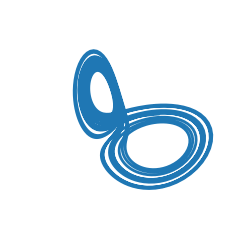

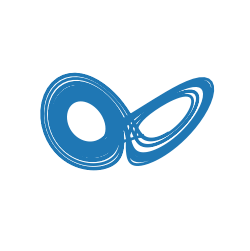

In [9]:
# Choose which experiment to visualize (you can change this string)
model_to_plot = 'lorenz_exp0_seed123'

res     = single_traj_results[model_to_plot]
z_sim   = res['z_sim']
lorenz_sim = res['lorenz_sim']

# 3D plot of the model's simulated attractor
fig1 = plt.figure(figsize=(3, 3))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(z_sim[:, 0], z_sim[:, 1], z_sim[:, 2], linewidth=2)
plt.axis('off')
ax1.view_init(azim=120)

# 3D plot of the ground-truth Lorenz trajectory
fig2 = plt.figure(figsize=(3, 3))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.plot(lorenz_sim[:, 0], lorenz_sim[:, 1], lorenz_sim[:, 2], linewidth=2)
plt.xticks([])
plt.axis('off')
ax2.view_init(azim=120)


#### Comparisons
    - Trajectories, Xi sparsity, and time courses

In [13]:
# True Xi (same for all columns)
Xi_true_plot = np.copy(test_data['sindy_coefficients'])
Xi_true_plot[Xi_true_plot == 0] = np.inf
# The original notebook did these manual fixes:
Xi_true_plot[6, 1] = -1.
Xi_true_plot[5, 2] = 1.


In [14]:
def get_Xi_plot_for_experiment(save_name):
    params = lorenz_experiments[save_name]['params']
    sindy_coeffs = single_traj_results[save_name]['test_set_results']['sindy_coefficients']
    Xi = params['coefficient_mask'] * sindy_coeffs
    Xi_plot = np.copy(Xi)
    Xi_plot[Xi_plot == 0] = np.inf
    return Xi_plot


##### Compare 2 experiments + ground truth

In [15]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def plot_lorenz_model_comparisons(
        exp_names,
        single_traj_results,
        Xi_true,
        get_Xi_plot_for_experiment,
        t,
        save_prefix="lorenz_compare",
        dpi=600,
        show=True,
):
    """
    Make one or more comparison figures.

    Each figure has:
      - left column:  true Lorenz (3D attractor + Xi_true + time series)
      - middle/right columns: up to two experiments from exp_names

    Parameters
    ----------
    exp_names : list of str
        Experiment names (keys in single_traj_results) to plot.
    single_traj_results : dict
        Mapping exp_name -> result dict (with keys 'lorenz_sim', 'z_sim',
        'test_set_results'->'z').
    Xi_true : np.ndarray
        Xi matrix for the true Lorenz system.
    get_Xi_plot_for_experiment : callable
        Function taking exp_name -> Xi matrix for that experiment.
    t : 1D array
        Time vector for the time series plots.
    save_prefix : str
        Prefix for the saved figure filenames.
    dpi : int
        Resolution for saved figures.
    show : bool
        Whether to call plt.show() at the end of each figure.
    """

    if len(exp_names) == 0:
        return

    # Use the first experiment entry to get the ground-truth Lorenz trajectory
    res0 = single_traj_results[exp_names[0]]
    lorenz_true = res0['lorenz_sim']
    z_true_ts   = lorenz_true  # for the lower panel we just plot truth vs truth

    # Process experiments in chunks of 2
    for fig_idx in range(0, len(exp_names), 2):
        group = exp_names[fig_idx:fig_idx+2]
        n_models = len(group)
        n_cols = 1 + n_models   # 1 for "True", then 1 or 2 models

        fig = plt.figure(figsize=(6 * n_cols, 9))
        outer = GridSpec(2, n_cols, height_ratios=[2, 3], hspace=0.4, wspace=0.3)

        # -------------------
        # Row 1: 3D attractors
        # -------------------
        # True Lorenz
        ax_true = fig.add_subplot(outer[0, 0], projection='3d')
        ax_true.plot(lorenz_true[:, 0], lorenz_true[:, 1], lorenz_true[:, 2],
                     color='#888888', linewidth=1)
        ax_true.set_title("True Lorenz")
        ax_true.view_init(azim=120)

        # Models
        for j, exp_name in enumerate(group):
            res = single_traj_results[exp_name]
            z_sim = res['z_sim']

            ax_model = fig.add_subplot(outer[0, 1 + j], projection='3d')
            ax_model.plot(z_sim[:, 0], z_sim[:, 1], z_sim[:, 2], linewidth=1)
            ax_model.set_title(exp_name)
            ax_model.view_init(azim=120)

        # -------------------
        # Row 2: Xi + time series
        # -------------------
        # Build the column definitions for the lower row
        columns = [("True", Xi_true, z_true_ts, lorenz_true)]
        for exp_name in group:
            res = single_traj_results[exp_name]
            Xi = get_Xi_plot_for_experiment(exp_name)
            z_ts = res['test_set_results']['z']
            z_sim = res['z_sim']
            columns.append((exp_name, Xi, z_ts, z_sim))

        for col_idx, (title, Xi, z_ts, z_sim) in enumerate(columns):
            inner = GridSpecFromSubplotSpec(
                1, 2,
                subplot_spec=outer[1, col_idx],
                width_ratios=[1, 6],
                wspace=0.5
            )

            # Xi sparsity
            ax_xi = fig.add_subplot(inner[0, 0])
            ax_xi.imshow(Xi, interpolation='none')
            ax_xi.set_title("Xi Sparsity", fontsize=8)
            ax_xi.set_xticks([])
            ax_xi.set_yticks([])
            ax_xi.axis('off')

            # Time courses
            ts_inner = GridSpecFromSubplotSpec(
                3, 1,
                subplot_spec=inner[0, 1],
                hspace=0.1
            )

            for i in range(3):
                ax_ts_i = fig.add_subplot(ts_inner[i, 0])
                ax_ts_i.plot(t, z_ts[:, i], color='#888888', linewidth=1.5)
                ax_ts_i.plot(t, z_sim[:, i], '--', linewidth=1)
                if i == 0:
                    ax_ts_i.set_title("Time Courses", fontsize=8)
                ax_ts_i.set_xlabel('t')
                ax_ts_i.set_ylabel(f'z{i+1}')

        # ---------
        # Save / show
        # ---------
        short_names = ["True"] + [name.split('_seed')[0] for name in group]
        suffix = "_vs_".join(short_names[1:])  # ignore "True" in filename
        filename = f"{save_prefix}_fig{fig_idx//2}_{suffix}.png"
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')
        if show:
            plt.show()
        else:
            plt.close(fig)


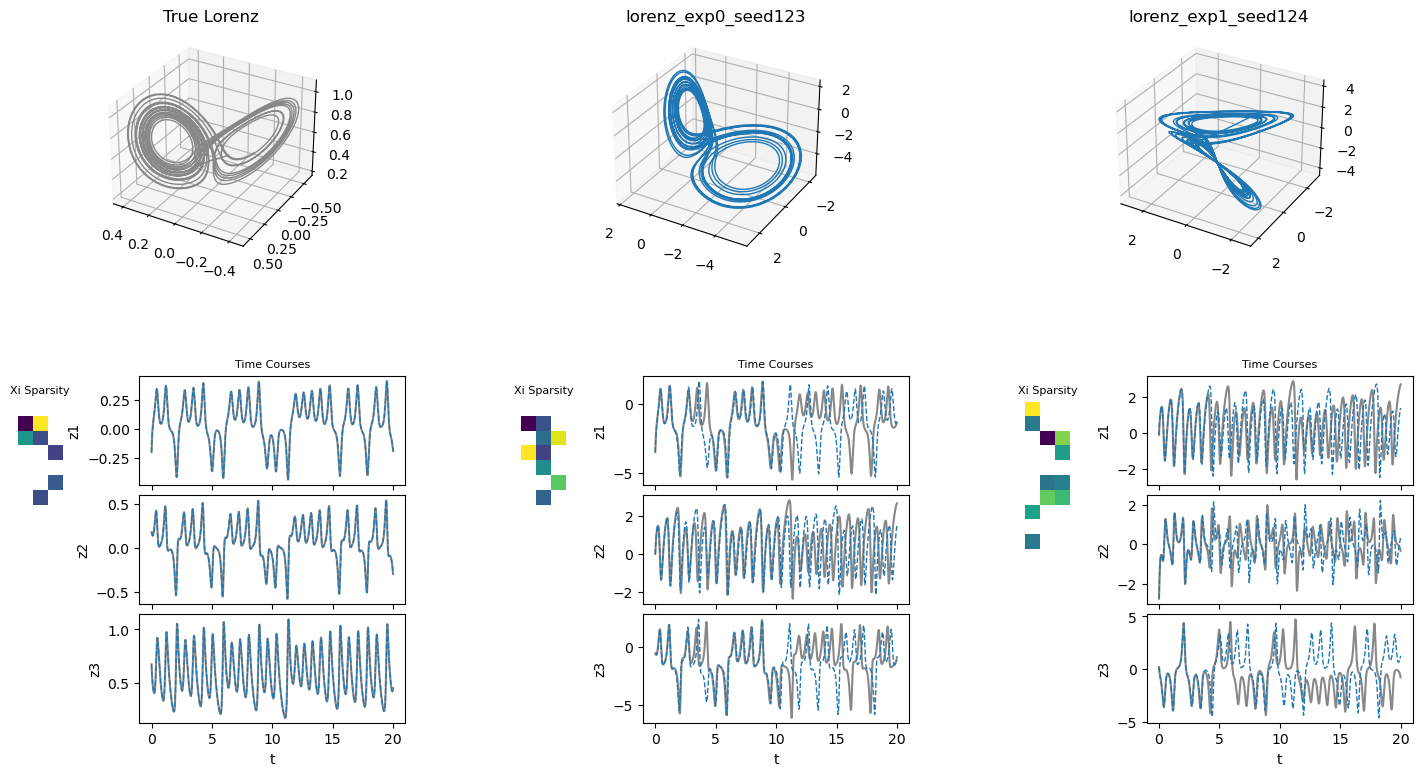

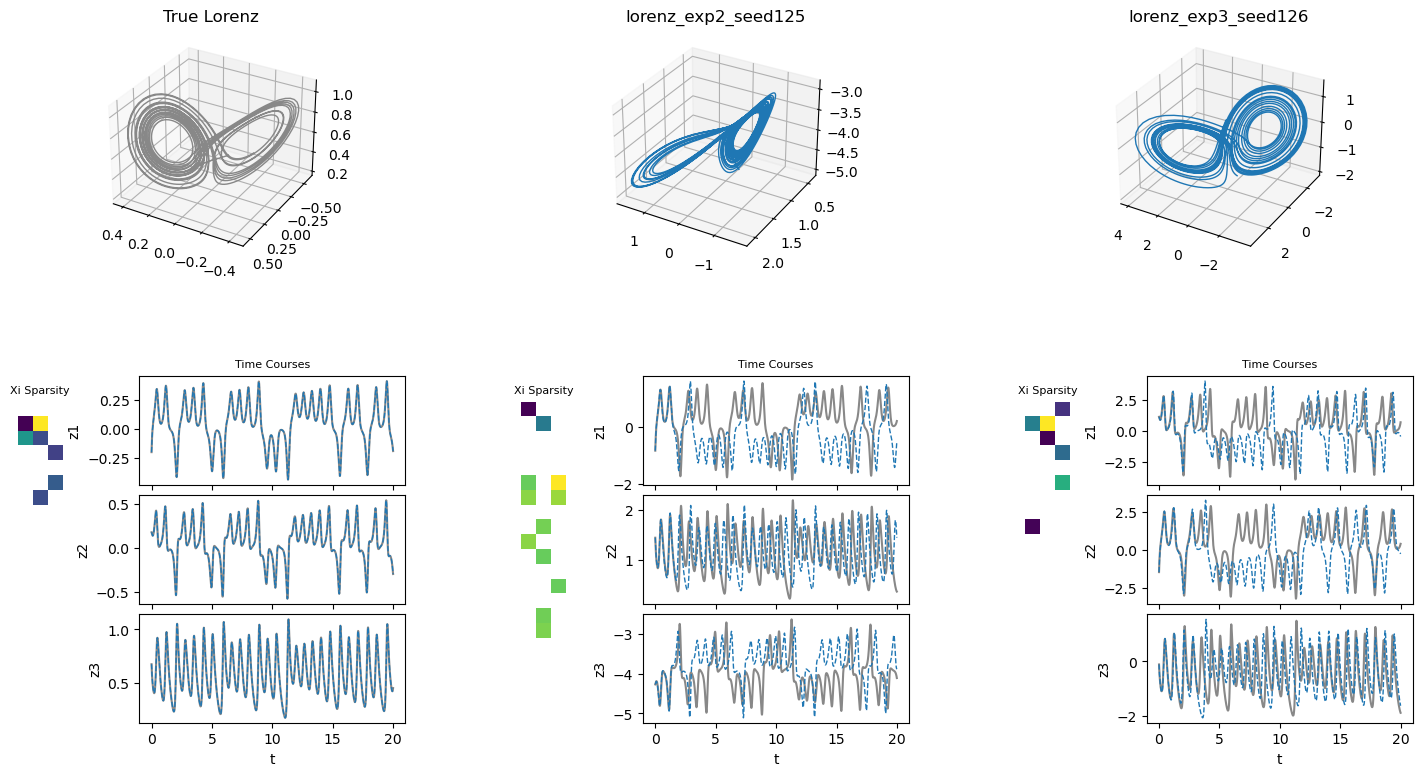

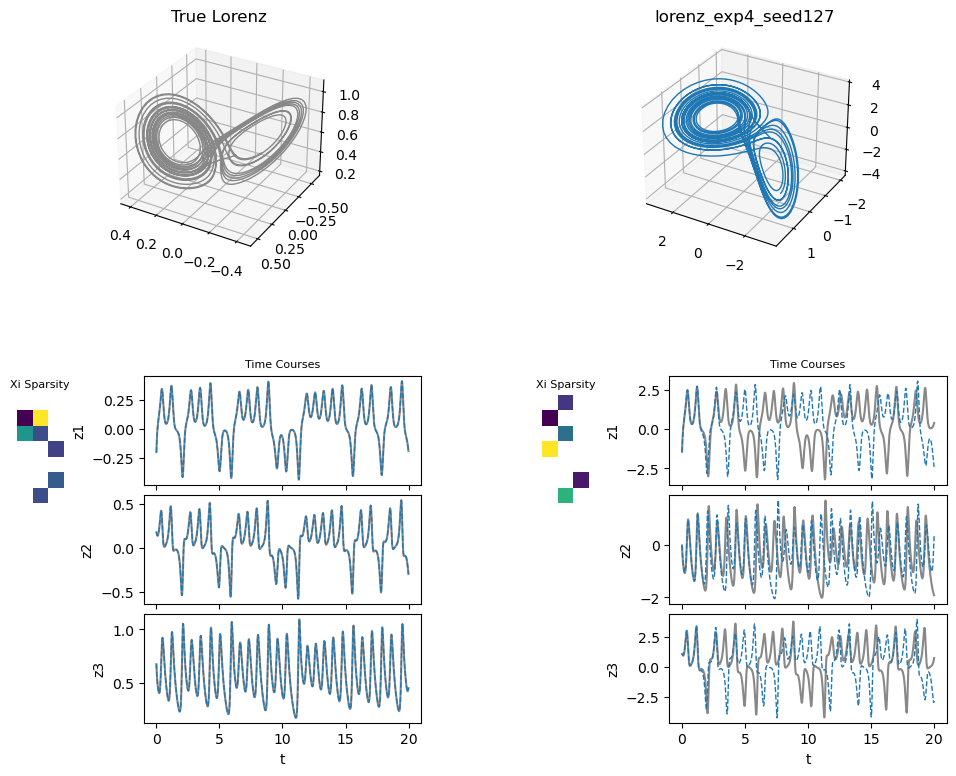

In [17]:
file_names = [
    'lorenz_exp0_seed123',
    'lorenz_exp1_seed124',
    'lorenz_exp2_seed125',
    'lorenz_exp3_seed126',
    'lorenz_exp4_seed127'
]

plot_lorenz_model_comparisons(
    exp_names=file_names,
    single_traj_results=single_traj_results,
    Xi_true=Xi_true_plot,
    get_Xi_plot_for_experiment=get_Xi_plot_for_experiment,
    t=t,
    save_prefix="mine/pics/lorenz_latsindy_compare",
)


#### This AE-SINDy environment has python 3.7, CEBRA needs at least 3.9
- Save and load in other notebook

In [10]:
test_data['z'].shape

(2000, 3)

In [11]:
emb_dict = {name: single_traj_results[name]['test_set_results']['z']
            for name in single_traj_results.keys()}

emb_dict['0true'] = test_data['z']

with open("lorenz_latent_embeddings_orig.pkl", "wb") as f:
    pickle.dump(emb_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

## Trying a Simple PCA/ICA

In [12]:
with open("lorenz_latent_embeddings_orig.pkl", "rb") as f:
    emb_dict = pickle.load(f)
run_names = sorted(emb_dict.keys())

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def affine_align(Z_src, Z_tgt):
    """
    Fit affine map Z_src -> Z_tgt and return aligned Z and R^2.
    """
    lm = LinearRegression(fit_intercept=True)
    lm.fit(Z_src, Z_tgt)
    Z_aligned = lm.predict(Z_src)
    r2 = r2_score(Z_tgt, Z_aligned, multioutput="uniform_average")
    return Z_aligned, r2


def plot_raw_and_aligned_embeddings(
    emb_dict,
    ref_name=None,
    show_names=None,
    azim=120,
    elev=None,
    figsize=(12, 9),
    title_raw="Raw embeddings (not aligned)",
    title_aln="Affine aligned to reference",
    label_ref="true",
    lw_ref=2,
    lw_other=1.0,
    alpha_ref=0.8,
    alpha_other=0.6,
    legend_fontsize=9,
    title_fontsize=20,
    save_path_raw=None,
    save_path_aln=None
):
    """
    Make TWO separate 3D plots:
      1) raw embeddings
      2) embeddings affine-aligned to a reference, with R^2 shown in legend

    Args:
      emb_dict: dict[str -> np.ndarray], each value shape (N, 3)
      ref_name: key in emb_dict to align everything to (default: first key in sorted order)
      show_names: list of keys to plot (default: all keys sorted)
      azim/elev: passed to ax.view_init
    """
    if not emb_dict:
        raise ValueError("emb_dict is empty.")

    # pick reference
    if ref_name is None:
        ref_name = sorted(emb_dict.keys())[0]
    if ref_name not in emb_dict:
        raise KeyError(f"ref_name='{ref_name}' not in emb_dict keys.")

    # choose what to show
    if show_names is None:
        show_names = sorted(emb_dict.keys())
    else:
        # keep only those present
        show_names = [k for k in show_names if k in emb_dict]
        if ref_name not in show_names:
            show_names = [ref_name] + show_names

    # sanity checks
    Z_ref = emb_dict[ref_name]
    if Z_ref.ndim != 2 or Z_ref.shape[1] != 3:
        raise ValueError(f"Reference embedding must be (N,3). Got {Z_ref.shape}.")
    N = Z_ref.shape[0]
    for k in show_names:
        Z = emb_dict[k]
        if Z.shape != (N, 3):
            raise ValueError(
                f"All embeddings must have identical shape (N,3). "
                f"Key '{k}' has {Z.shape}, reference has {(N,3)}."
            )

    # compute aligned + R^2
    aligned = {ref_name: Z_ref}
    r2s = {ref_name: 1.0}
    for k in show_names:
        if k == ref_name:
            continue
        aligned[k], r2s[k] = affine_align(emb_dict[k], Z_ref)

    # ---------- FIG 1: RAW ----------
    fig_raw = plt.figure(figsize=figsize)
    ax_raw = fig_raw.add_subplot(111, projection="3d")

    for k in show_names:
        Z = emb_dict[k]
        if k == ref_name:
            ax_raw.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_ref, alpha=alpha_ref, label=label_ref
            )
        else:
            ax_raw.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_other, alpha=alpha_other, label=k
            )

    ax_raw.set_title(title_raw, fontsize=title_fontsize)
    if elev is None:
        ax_raw.view_init(azim=azim)
    else:
        ax_raw.view_init(elev=elev, azim=azim)
    ax_raw.legend(fontsize=legend_fontsize)
    plt.tight_layout()
    plt.show()

    # ---------- FIG 2: ALIGNED ----------
    fig_aln = plt.figure(figsize=figsize)
    ax_aln = fig_aln.add_subplot(111, projection="3d")

    for k in show_names:
        Z = aligned[k]
        if k == ref_name:
            ax_aln.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_ref, alpha=alpha_ref, label=label_ref
            )
        else:
            ax_aln.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_other, alpha=alpha_other,
                label=f"{k}  (R$^2$={r2s[k]:.3f})"
            )

    ax_aln.set_title(title_aln, fontsize=title_fontsize)
    if elev is None:
        ax_aln.view_init(azim=azim)
    else:
        ax_aln.view_init(elev=elev, azim=azim)
    ax_aln.legend(fontsize=legend_fontsize)
    plt.tight_layout()
    plt.show()

    if save_path_raw is not None:
        fig_raw.savefig(save_path_raw, dpi=600)
    if save_path_aln is not None:
        fig_aln.savefig(save_path_aln, dpi=600)

    return aligned, r2s


In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA

# --- Your base data ---
X = test_data["x"]   # (N, input_dim)
Z_gt = test_data["z"]  # (N, 3)

# --- Standardize X once (for PCA/ICA) ---
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# --- PCA (3D) ---
pca = PCA(n_components=3, random_state=0)
Z_pca = pca.fit_transform(X_std)  # (N, 3)

# --- ICA (3D) ---
ica = FastICA(n_components=3, random_state=0, max_iter=2000, tol=1e-4)
Z_ica = ica.fit_transform(X_std)  # (N, 3)

# --- Construct emb_dict_all ---
emb_dict_all = {}

# ground truth
emb_dict_all["gt"] = np.asarray(Z_gt)

# baselines
emb_dict_all["pca"] = np.asarray(Z_pca)
emb_dict_all["ica"] = np.asarray(Z_ica)

# add all AE-SINDy runs
for k, Z in emb_dict.items():
    emb_dict_all[k] = np.asarray(Z)

# quick sanity check
N = emb_dict_all["gt"].shape[0]
for k, Z in emb_dict_all.items():
    assert Z.shape == (N, 3), f"{k} has shape {Z.shape}, expected {(N,3)}"


In [15]:
emb_dict_all.keys()

dict_keys(['gt', 'pca', 'ica', 'lorenz_exp0_seed123', 'lorenz_exp1_seed124', 'lorenz_exp2_seed125', 'lorenz_exp3_seed126', 'lorenz_exp4_seed127', 'lorenz_exp5_seed128', 'lorenz_exp6_seed129', 'lorenz_exp7_seed130', 'lorenz_exp8_seed131', 'lorenz_exp9_seed132', 'lorenz_exp10_seed133', 'lorenz_exp11_seed134', 'lorenz_exp12_seed135', 'lorenz_exp13_seed136', 'lorenz_exp14_seed137', 'lorenz_exp15_seed138', '0true'])

In [16]:
disp_names = ['lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149',
              'lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150',
              'lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146']
emb_dict_disp = {}
emb_dict_disp['GT'] = emb_dict_all['gt']
emb_dict_disp['PCA'] = emb_dict_all['pca']
emb_dict_disp['ICA'] = emb_dict_all['ica']
emb_dict_disp['AE-SINDy'] = emb_dict_all['lorenz_exp0_seed123']
#emb_dict_disp['AE-mid'] = emb_dict_all['lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146']
#emb_dict_disp['AE-worst'] = emb_dict_all['lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150']

In [17]:
emb_dict_disp.keys()

dict_keys(['GT', 'PCA', 'ICA', 'AE-SINDy'])

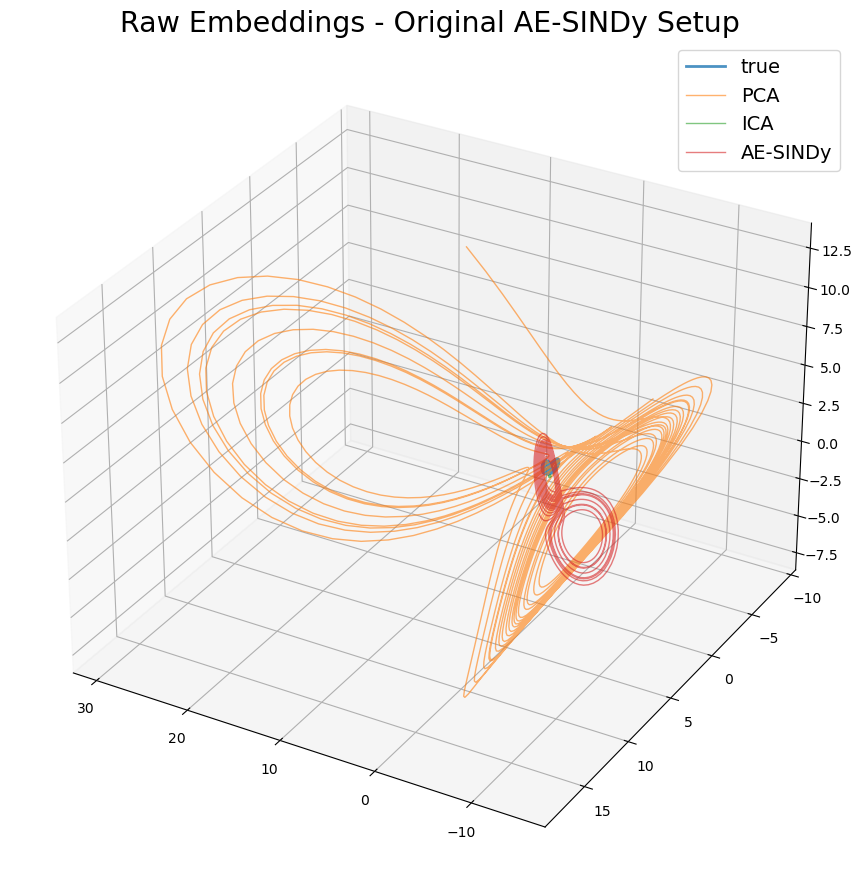

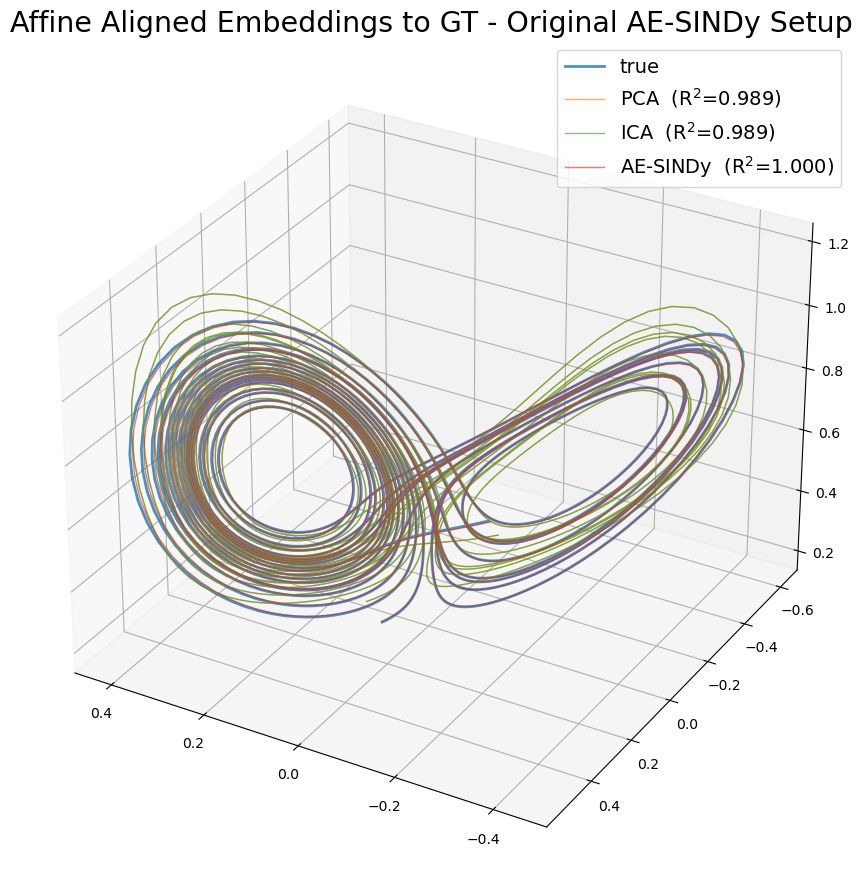

In [18]:
# Example: align everything to GT and plot a subset
aligned, r2s = plot_raw_and_aligned_embeddings(
    emb_dict_disp,
    ref_name="GT",
    show_names=emb_dict_disp.keys(),
    title_raw="Raw Embeddings - Original AE-SINDy Setup",
    title_aln="Affine Aligned Embeddings to GT - Original AE-SINDy Setup",
    legend_fontsize=14,
    save_path_raw='pics/raw_embeddings_orig_mixing',
    save_path_aln='pics/aligned_embeddings_orig_mixing',
    title_fontsize=20.5
)

In [163]:
disp_names = ['lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149',
              'lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150',
              'lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146']
emb_dict_disp = {}
emb_dict_disp['GT'] = emb_dict_all['gt']
emb_dict_disp['PCA'] = emb_dict_all['pca']
emb_dict_disp['AE-best'] = emb_dict_all['lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149']
#emb_dict_disp['AE-mid'] = emb_dict_all['lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146']
emb_dict_disp['AE-worst'] = emb_dict_all['lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150']

In [148]:
emb_dict_disp.keys()

dict_keys(['pca', 'gt', 'AE-best', 'AE-mid', 'AE-worst'])

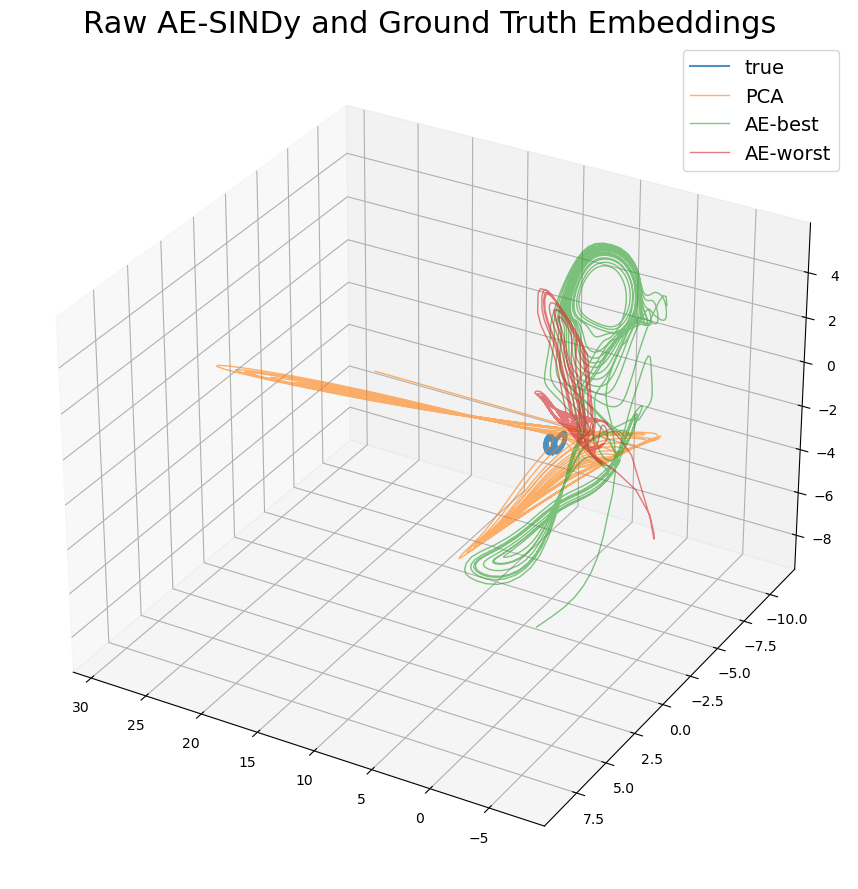

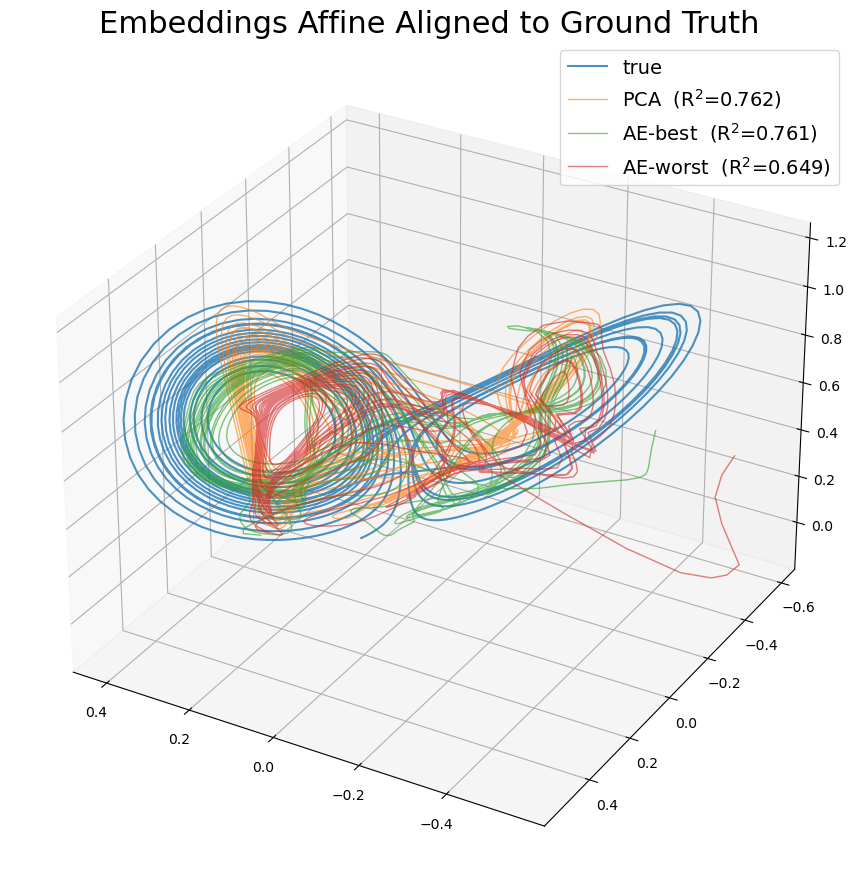

In [ ]:
# Example: align everything to GT and plot a subset
aligned, r2s = plot_raw_and_aligned_embeddings(
    emb_dict_disp,
    ref_name="GT",
    show_names=emb_dict_disp.keys(),
    title_raw="Raw Embeddings - Altered AE-SINDy Setup",
    title_aln="Affine Aligned Embeddings to GT - Altered AE-SINDy Setup",
    legend_fontsize=14,
    save_path_raw='pics/raw_embeddings_nonlin_mlp_mixing',
    save_path_aln='pics/aligned_embeddings_nonlin_mlp_mixing',
    title_fontsize=22
)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def affine_align(Z_src, Z_tgt):
    """Fit affine map Z_src -> Z_tgt and return aligned Z and R^2."""
    lm = LinearRegression(fit_intercept=True)
    lm.fit(Z_src, Z_tgt)
    Z_aligned = lm.predict(Z_src)
    r2 = r2_score(Z_tgt, Z_aligned, multioutput="uniform_average")
    return Z_aligned, r2


def plot_embeddings_grid_raw_and_aligned(
    emb_dict,
    ref_name=None,
    show_names=None,
    azim=120,
    elev=None,
    figsize_per_col=(4.2, 3.3),   # (width, height) per column
    suptitle=None,
    lw=1.0,
    lw_ref=1.4,
    alpha=0.85,
    alpha_ref=0.95,
    title_fontsize=16,
    subplot_title_fontsize=12,
    label_fontsize=11,
    tick_fontsize=9,
    show_axes=True,              # set False to mimic "cleaner" look
    save_path=None,              # e.g. "pics/grid_embeddings.png"
    dpi=600,
):
    """
    Create a 2xK grid of 3D plots:
      - row 0: raw embeddings
      - row 1: affine-aligned embeddings to ref_name

    Columns correspond to the keys in show_names (or all keys).
    R^2 is shown for aligned plots (row 1) in the subplot title.

    Returns:
      aligned: dict of aligned embeddings
      r2s: dict of R^2 values w.r.t. reference
    """
    if not emb_dict:
        raise ValueError("emb_dict is empty.")

    # pick reference
    if ref_name is None:
        ref_name = sorted(emb_dict.keys())[0]
    if ref_name not in emb_dict:
        raise KeyError(f"ref_name='{ref_name}' not in emb_dict keys.")

    # choose what to show, keep order
    if show_names is None:
        show_names = list(sorted(emb_dict.keys()))
    else:
        show_names = [k for k in show_names if k in emb_dict]
    if ref_name not in show_names:
        show_names = [ref_name] + show_names

    # sanity checks: all same shape (N,3)
    Z_ref = np.asarray(emb_dict[ref_name])
    if Z_ref.ndim != 2 or Z_ref.shape[1] != 3:
        raise ValueError(f"Reference embedding must be (N,3). Got {Z_ref.shape}.")
    N = Z_ref.shape[0]
    for k in show_names:
        Z = np.asarray(emb_dict[k])
        if Z.shape != (N, 3):
            raise ValueError(
                f"All embeddings must have identical shape (N,3). "
                f"Key '{k}' has {Z.shape}, reference has {(N,3)}."
            )

    # compute aligned + R^2
    aligned = {ref_name: Z_ref}
    r2s = {ref_name: 1.0}
    for k in show_names:
        if k == ref_name:
            continue
        aligned[k], r2s[k] = affine_align(np.asarray(emb_dict[k]), Z_ref)

    # figure sizing: scale by number of columns
    K = len(show_names)
    fig_w = figsize_per_col[0] * K
    fig_h = figsize_per_col[1] * 2
    fig = plt.figure(figsize=(fig_w, fig_h))

    def _format_ax(ax):
        if elev is None:
            ax.view_init(azim=azim)
        else:
            ax.view_init(elev=elev, azim=azim)

        # cosmetic: optionally hide axes
        if not show_axes:
            ax.set_axis_off()
        else:
            ax.tick_params(labelsize=tick_fontsize)

    # make subplots
    for col, name in enumerate(show_names):
        # --- RAW (row 0) ---
        ax_raw = fig.add_subplot(2, K, 1 + col, projection="3d")
        Z = np.asarray(emb_dict[name])
        ax_raw.plot(
            Z[:, 0], Z[:, 1], Z[:, 2],
            linewidth=(lw_ref if name == ref_name else lw),
            alpha=(alpha_ref if name == ref_name else alpha),
        )
        ax_raw.set_title(f"{name}", fontsize=subplot_title_fontsize)
        _format_ax(ax_raw)

        # --- ALIGNED (row 1) ---
        ax_aln = fig.add_subplot(2, K, 1 + K + col, projection="3d")
        Za = aligned[name]
        ax_aln.plot(
            Za[:, 0], Za[:, 1], Za[:, 2],
            linewidth=(lw_ref if name == ref_name else lw),
            alpha=(alpha_ref if name == ref_name else alpha),
        )

        if name == ref_name:
            ax_aln.set_title(f"{name} (ref)", fontsize=subplot_title_fontsize)
        else:
            ax_aln.set_title(f"{name}  (R$^2$={r2s[name]:.3f})", fontsize=subplot_title_fontsize)
        _format_ax(ax_aln)

    # row labels (clear indication of what is what)
    fig.text(0.5, 0.98, suptitle if suptitle else "", ha="center", va="top",
             fontsize=title_fontsize)

    fig.text(0.01, 0.75, "Raw", rotation=90, ha="left", va="center", fontsize=label_fontsize)
    fig.text(0.01, 0.25, f"Affine aligned to {ref_name}", rotation=90,
             ha="left", va="center", fontsize=label_fontsize)

    plt.tight_layout(rect=[0.03, 0.02, 1.00, 0.95])
    plt.subplots_adjust(hspace=0.2)

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()
    return aligned, r2s


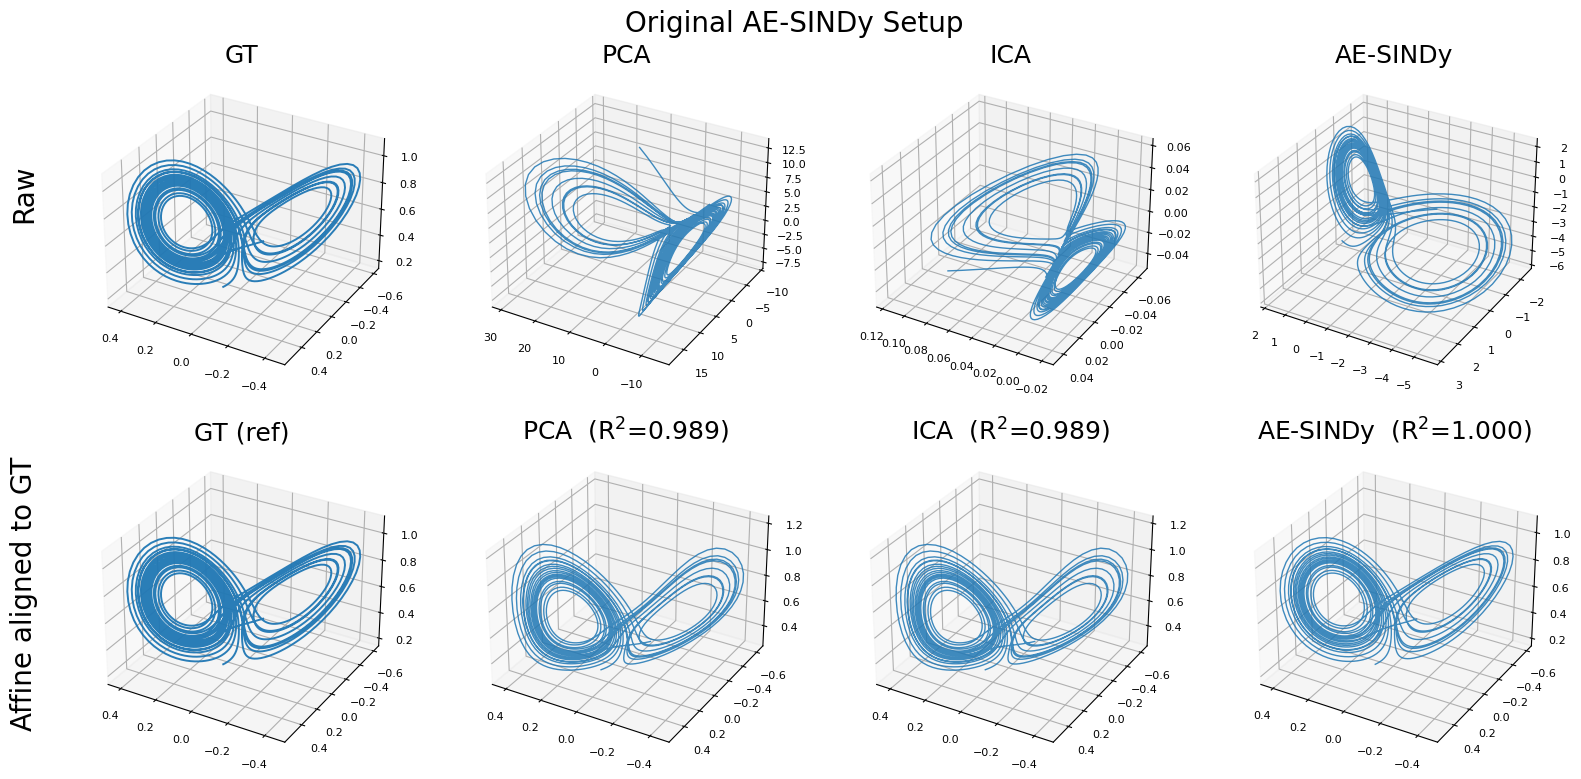

In [20]:
aligned, r2s = plot_embeddings_grid_raw_and_aligned(
    emb_dict_disp,
    ref_name="GT",
    show_names=["GT", "PCA", "ICA", "AE-SINDy"],
    azim=120,
    figsize_per_col=(4, 4),#=(4.2, 3.3),
    suptitle="Original AE-SINDy Setup",
    show_axes=True,                      # or False for a cleaner look
    save_path="pics/embeddings_grid_orig.png",
    title_fontsize=20,
    subplot_title_fontsize=18,
    tick_fontsize=8,
    label_fontsize=20
)
